In [6]:
import sys, os
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'true'
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '0.99'
os.environ['NUMBA_NUM_THREADS'] = str(os.cpu_count())
print("NUMBA_NUM_THREADS set to: ", os.environ['NUMBA_NUM_THREADS'])
import jax
from jax import config
import numpy as np
from discodj import DiscoDJ
import jax.numpy as jnp
from jax._src.lib import xla_client
import gc
import MAS_library as MASL
import pickle as pk
import skimage.measure as skmeasure
from mpi4py import MPI
from scipy.ndimage import convolve
import time
from numba import njit, prange

# =============================================================================
# TIMING UTILITIES
# =============================================================================
ENABLE_TIMING = True

class Timer:
    """Simple timer using explicit start/stop calls."""
    def __init__(self, enabled=True):
        self.enabled = enabled
        self.records = {}
        self._start_times = {}
    
    def start(self, name):
        if self.enabled:
            self._start_times[name] = time.perf_counter()
    
    def stop(self, name):
        if not self.enabled:
            return
        if name not in self._start_times:
            return
        elapsed = time.perf_counter() - self._start_times[name]
        if name not in self.records:
            self.records[name] = []
        self.records[name].append(elapsed)
        print(f"[TIMER] {name}: {elapsed:.4f}s")
        del self._start_times[name]
    
    def summary(self):
        if not self.enabled or not self.records:
            return
        print("\n" + "="*60)
        print("TIMING SUMMARY")
        print("="*60)
        for name, times in sorted(self.records.items(), key=lambda x: -sum(x[1])):
            total = sum(times)
            avg = total / len(times)
            print(f"{name:40s} | total: {total:8.3f}s | calls: {len(times):3d} | avg: {avg:.4f}s")
        print("="*60 + "\n")
    
    def reset(self):
        self.records = {}
        self._start_times = {}

timer = Timer(enabled=ENABLE_TIMING)

# =============================================================================
# NUMBA-ACCELERATED FUNCTIONS
# =============================================================================

@njit(parallel=True, fastmath=True, cache=True)
def _get_padded_mat_numba_core(Npart_pad, n_pad, grid_sbox, grid, fac):
    """
    Numba-parallelized extraction and block reduction.
    Avoids creating massive intermediate arrays.
    """
    fac3_inv = np.float32(1.0 / (fac * fac * fac))
    result = np.zeros((grid, grid, grid, grid_sbox, grid_sbox, grid_sbox), dtype=np.float32)
    
    # Parallelize over all grid cells
    for idx in prange(grid * grid * grid):
        gi = idx // (grid * grid)
        gj = (idx // grid) % grid
        gk = idx % grid
        
        # Starting position in padded array
        i0 = gi * grid_sbox
        j0 = gj * grid_sbox
        k0 = gk * grid_sbox
        
        for si in range(grid_sbox):
            i_base = i0 + si * fac
            for sj in range(grid_sbox):
                j_base = j0 + sj * fac
                for sk in range(grid_sbox):
                    k_base = k0 + sk * fac
                    
                    # Sum over the fac^3 block
                    total = np.float32(0.0)
                    for di in range(fac):
                        for dj in range(fac):
                            for dk in range(fac):
                                total += Npart_pad[i_base + di, j_base + dj, k_base + dk]
                    
                    result[gi, gj, gk, si, sj, sk] = total * fac3_inv
    
    return result


@njit(parallel=True, fastmath=True, cache=True)
def _velocity_field_numba(pos, vel, Npart_cic, BoxSize, grid_tot, norm_vel):
    """
    Compute velocity field with momentum weighting.
    Returns velocity field of shape (grid_tot, grid_tot, grid_tot, 3)
    """
    vel_field = np.zeros((grid_tot, grid_tot, grid_tot, 3), dtype=np.float32)
    mom_field = np.zeros((grid_tot, grid_tot, grid_tot, 3), dtype=np.float32)
    
    cell_size = BoxSize / grid_tot
    n_part = pos.shape[0]
    
    # CIC assignment for momentum
    for p in prange(n_part):
        # Get cell indices
        x = pos[p, 0] / cell_size
        y = pos[p, 1] / cell_size
        z = pos[p, 2] / cell_size
        
        # Integer and fractional parts
        i = int(x)
        j = int(y)
        k = int(z)
        
        dx = x - i
        dy = y - j
        dz = z - k
        
        # Wrap indices
        i0 = i % grid_tot
        j0 = j % grid_tot
        k0 = k % grid_tot
        i1 = (i + 1) % grid_tot
        j1 = (j + 1) % grid_tot
        k1 = (k + 1) % grid_tot
        
        # CIC weights
        w000 = (1 - dx) * (1 - dy) * (1 - dz)
        w001 = (1 - dx) * (1 - dy) * dz
        w010 = (1 - dx) * dy * (1 - dz)
        w011 = (1 - dx) * dy * dz
        w100 = dx * (1 - dy) * (1 - dz)
        w101 = dx * (1 - dy) * dz
        w110 = dx * dy * (1 - dz)
        w111 = dx * dy * dz
        
        for c in range(3):
            v = vel[p, c]
            mom_field[i0, j0, k0, c] += w000 * v
            mom_field[i0, j0, k1, c] += w001 * v
            mom_field[i0, j1, k0, c] += w010 * v
            mom_field[i0, j1, k1, c] += w011 * v
            mom_field[i1, j0, k0, c] += w100 * v
            mom_field[i1, j0, k1, c] += w101 * v
            mom_field[i1, j1, k0, c] += w110 * v
            mom_field[i1, j1, k1, c] += w111 * v
    
    # Divide by density to get velocity
    norm_vel_inv = np.float32(1.0 / norm_vel)
    for i in prange(grid_tot):
        for j in range(grid_tot):
            for k in range(grid_tot):
                n = Npart_cic[i, j, k]
                if n > 0:
                    for c in range(3):
                        vel_field[i, j, k, c] = mom_field[i, j, k, c] / n * norm_vel_inv
    
    return vel_field


def get_padded_mat_numba(Npart, n_pad, grid_sbox, grid):
    """Wrapper for numba-accelerated padded matrix computation."""
    timer.start("get_padded_mat:pad")
    Npart_pad = np.pad(Npart, n_pad, mode='wrap').astype(np.float32)
    timer.stop("get_padded_mat:pad")
    
    box_size = grid_sbox + 2 * n_pad
    fac = box_size // grid_sbox
    
    timer.start("get_padded_mat:numba_core")
    result = _get_padded_mat_numba_core(Npart_pad, n_pad, grid_sbox, grid, fac)
    timer.stop("get_padded_mat:numba_core")
    
    return result, None


# =============================================================================
# PROCESSING FUNCTIONS
# =============================================================================

def mat_reshape_fast(mat, grid, grid_sbox):
    """Single reshape + transpose instead of multiple moveaxis"""
    grid_tot = grid * grid_sbox
    if mat.ndim == 3:
        return mat.reshape(grid, grid_sbox, grid, grid_sbox, grid, grid_sbox).transpose(0, 2, 4, 1, 3, 5)
    else:
        extra_dims = mat.shape[3:]
        return mat.reshape(grid, grid_sbox, grid, grid_sbox, grid, grid_sbox, *extra_dims).transpose(0, 2, 4, 1, 3, 5, *range(6, 6+len(extra_dims)))


def process_LH_sim_fast(pos_m_truth, vel_m_truth, get_env=False, get_vel=False, 
                        get_randsel=False, grid=64, grid_sbox=8, nrand_sel_box=32768, BoxSize = 3000., norm_delta = 10, norm_vel = 100):
    # norm_delta = 10
    # norm_vel = 100
    # BoxSize = 1000.
    MAS_type = 'CIC'
    grid_tot = grid_sbox * grid

    rho_bar = len(pos_m_truth) / (BoxSize**3)
    vol_vox = (BoxSize / grid_tot)**3
    N_bar_vox = rho_bar * vol_vox

    # Density field
    timer.start("process:density_MAS")
    Npart = np.zeros((grid_tot, grid_tot, grid_tot), dtype=np.float32)
    pos_copy = np.array(pos_m_truth, dtype=np.float32, copy=True)
    MASL.MA(pos_copy, Npart, BoxSize, MAS_type, verbose=False)
    # Npart /= (N_bar_vox * norm_delta)
    timer.stop("process:density_MAS")

    timer.start("process:density_reshape")
    Npart_rs = mat_reshape_fast(Npart, grid, grid_sbox)
    timer.stop("process:density_reshape")
    
    fields_list = [Npart_rs[..., None]/(N_bar_vox * norm_delta), np.log1p(Npart_rs)[..., None]]
    
    if get_env or get_vel:
        timer.start("process:cic_for_vel_env")
        Npart_cic = np.zeros((grid_tot, grid_tot, grid_tot), dtype=np.float32)
        MASL.MA(pos_copy, Npart_cic, BoxSize, 'CIC', verbose=False)
        timer.stop("process:cic_for_vel_env")
    
    if get_env:
        # Use numba-accelerated version
        timer.start("process:env_pad1")
        Npart_pad1_rs, _ = get_padded_mat_numba(Npart, grid_sbox, grid_sbox, grid)
        timer.stop("process:env_pad1")
        
        timer.start("process:env_pad2")
        Npart_pad2_rs, _ = get_padded_mat_numba(Npart, 2*grid_sbox, grid_sbox, grid)
        timer.stop("process:env_pad2")
        fields_list.extend([Npart_pad1_rs[..., None]/(N_bar_vox * norm_delta), np.log1p(Npart_pad1_rs)[..., None], Npart_pad2_rs[..., None]/(N_bar_vox * norm_delta)])

    if get_vel:
        timer.start("process:velocity_field")
        vel_m_part = np.zeros((grid_tot, grid_tot, grid_tot, 3), dtype=np.float32)
        vel_copy = np.array(vel_m_truth, dtype=np.float32, copy=True)
        
        for jc in range(3):
            mom_jc = np.zeros((grid_tot, grid_tot, grid_tot), dtype=np.float32)
            MASL.MA(pos_copy, mom_jc, BoxSize, 'CIC', verbose=False, W=vel_copy[:, jc])
            
            vel_m_jc = np.divide(mom_jc, Npart_cic, out=np.zeros_like(mom_jc), 
                                  where=Npart_cic != 0)
            vel_m_part[..., jc] = vel_m_jc / norm_vel
        timer.stop("process:velocity_field")

        timer.start("process:velocity_reshape")
        vel_m_part_rs = mat_reshape_fast(vel_m_part, grid, grid_sbox)
        timer.stop("process:velocity_reshape")
        fields_list.append(vel_m_part_rs)

    timer.start("process:concatenate")
    dmo_fields_all_snap = np.concatenate(fields_list, axis=-1)
    dmo_fields_all_rs = dmo_fields_all_snap.reshape((grid**3, *dmo_fields_all_snap.shape[3:]))
    timer.stop("process:concatenate")

    # Random selection
    if (nrand_sel_box < grid**3) and get_randsel:
        timer.start("process:random_selection")
        rng = np.random.default_rng(0)
        Npart_sum = dmo_fields_all_rs[..., 0].sum(axis=(1, 2, 3))
        
        npart_min, npart_max = np.percentile(Npart_sum, [2.0, 98.0])
        Npart_clipped = np.clip(Npart_sum, npart_min, npart_max)
        
        hist, bins_edges = np.histogram(Npart_clipped, bins=16)
        bins_edges[0], bins_edges[-1] = 0.0, bins_edges[-1] * 100
        nsel_per_jb = nrand_sel_box // len(hist)

        indsel_all = []
        for jbd in range(len(bins_edges) - 1):
            indsel = np.where((Npart_sum >= bins_edges[jbd]) & 
                             (Npart_sum < bins_edges[jbd + 1]))[0]
            n_sel = min(len(indsel), nsel_per_jb)
            if n_sel > 0:
                indsel_all.append(rng.choice(indsel, n_sel, replace=False))

        indsel_all = np.concatenate(indsel_all)
        
        if len(indsel_all) < nrand_sel_box:
            remaining = np.setdiff1d(np.arange(grid**3), indsel_all)
            indsel_all = np.concatenate([
                indsel_all, 
                rng.choice(remaining, nrand_sel_box - len(indsel_all), replace=False)
            ])

        rand_sel = rng.permutation(indsel_all)
        Npart_sum_sel = Npart_sum[rand_sel]
        timer.stop("process:random_selection")
    else:
        rand_sel = np.arange(grid**3)
        Npart_sum = Npart_sum_sel = 0

    # any non-finite values set to zero:
    dmo_fields_all_rs[~np.isfinite(dmo_fields_all_rs)] = 0.0

    return dmo_fields_all_rs, rand_sel, Npart_sum, Npart_sum_sel, norm_delta, norm_vel


# =============================================================================
# WARMUP NUMBA (compile before timing)
# =============================================================================
def warmup_numba():
    """Pre-compile numba functions to avoid JIT overhead in timing."""
    print("Warming up numba functions...")
    dummy = np.random.randn(64, 64, 64).astype(np.float32)
    dummy_pad = np.pad(dummy, 4, mode='wrap').astype(np.float32)
    _ = _get_padded_mat_numba_core(dummy_pad, 4, 8, 8, 3)
    print("Numba warmup complete.")



NUMBA_NUM_THREADS set to:  64


--------------------------------------------------------------------------
Ignoring value for oob_tcp_if_exclude on workergpu017 (10.250.112.0/20: Did not find interface matching this subnet).
(You can safely ignore this message.)
--------------------------------------------------------------------------


In [7]:
norm_delta = 10.
norm_vel = 100.
BoxSize = 1000. * 3
grid = 64 * 3
grid_sbox = 8
nrand_sel_box = (grid)**3

MAS_type = 'CIC'
grid_tot = grid_sbox * grid

z_snaps = [2, 1, 0.5]

sim_id = 663
root_out = f'/mnt/ceph/users/spandey/discodj_runs/test_3gpc/full_rhog_LH/{sim_id}/'
savefname_dmo_fields = root_out + 'dmo_fields_subvols_grid_%d_LH_%d.npy' % (grid_sbox, sim_id)
meta_fname = root_out + 'meta_dmo_fields_subvols_grid_%d_LH_%d.pkl' % (grid_sbox, sim_id)



for js, z in enumerate(z_snaps):
    import numpy as np
    np.random.seed(0)
    # pos_m_truth = np.load(root_in + '/pos_LH%d_z05.npy' % ji)
    # vel_m_truth = np.load(root_in + '/vel_LH%d_z05.npy' % ji)         

    timer.start(f"reading_sim_snap_{js}")
    import h5py as h5
    import numpy as np
    df = h5.File(f'/mnt/ceph/users/spandey/discodj_runs/test_3gpc/LH/{sim_id}/SNAPSHOT_fastpm_B2_z{z}.hdf5', 'r')
    pos_m_truth = np.array(df['Position'], dtype=np.float32)
    vel_m_truth = np.array(df['Velocity'], dtype=np.float32)
    print("Position shape: ", pos_m_truth.shape)
    print("Velocity shape: ", vel_m_truth.shape)
    df.close()
    timer.stop(f"reading_sim_snap_{js}")

    if js == 1:
        get_env, get_vel, get_randsel = True, True, False
    elif js == 2:
        get_env, get_vel, get_randsel = True, True, True
    else:
        get_env, get_vel, get_randsel = False, False, False

    rand_sel = np.arange(grid**3)


    timer.start(f"process_sim_snap_{js}")
    dmo_fields_all_rs, rand_sel, Npart_sum, Npart_sum_sel, norm_delta, norm_vel = process_LH_sim_fast(
        pos_m_truth, vel_m_truth, get_env=get_env, get_vel=get_vel, get_randsel=get_randsel,
        grid_sbox=grid_sbox, grid=grid, nrand_sel_box=nrand_sel_box, BoxSize=BoxSize, norm_delta=norm_delta, norm_vel=norm_vel
    )
    timer.stop(f"process_sim_snap_{js}")

    if js == 0:
        dmo_fields_all_rs_all = dmo_fields_all_rs
    else:
        timer.start(f"concat_snap_{js}")
        dmo_fields_all_rs_all = np.concatenate((dmo_fields_all_rs_all, dmo_fields_all_rs), axis=-1)
        timer.stop(f"concat_snap_{js}")

    del pos_m_truth, vel_m_truth, dmo_fields_all_rs
    gc.collect()
    jax.clear_caches()


    timer.start("save_outputs")
    np.save(savefname_dmo_fields, dmo_fields_all_rs_all.astype(np.float16)[rand_sel, ...])
    saved = {
        # 'cosmo':cosmo,
        'zsnaps': z_snaps,
        'Npart_sum_all': Npart_sum,
        'Npart_sum_sel': Npart_sum_sel,
        'norm_delta': norm_delta,
        'norm_vel': norm_vel,
        'grid_sbox': grid_sbox,
        'grid': grid,
        'rand_sel': rand_sel
    }
    pk.dump(saved, open(meta_fname, 'wb'))
    timer.stop("save_outputs")




Position shape:  (3623878656, 3)
Velocity shape:  (3623878656, 3)
[TIMER] reading_sim_snap_0: 619.4510s
[TIMER] process:density_MAS: 76.9222s
[TIMER] process:density_reshape: 0.0000s
[TIMER] process:concatenate: 20.6787s
[TIMER] process_sim_snap_0: 109.6214s
[TIMER] save_outputs: 76.7048s
Position shape:  (3623878656, 3)
Velocity shape:  (3623878656, 3)
[TIMER] reading_sim_snap_1: 506.6707s
[TIMER] process:density_MAS: 81.1163s
[TIMER] process:density_reshape: 0.0000s
[TIMER] process:cic_for_vel_env: 71.6153s
[TIMER] get_padded_mat:pad: 9.7976s
[TIMER] get_padded_mat:numba_core: 8.2038s
[TIMER] process:env_pad1: 18.0279s
[TIMER] get_padded_mat:pad: 6.9250s
[TIMER] get_padded_mat:numba_core: 18.1129s
[TIMER] process:env_pad2: 25.0632s
[TIMER] process:velocity_field: 341.3994s
[TIMER] process:velocity_reshape: 0.0000s
[TIMER] process:concatenate: 198.0554s
[TIMER] process_sim_snap_1: 810.6325s
[TIMER] concat_snap_1: 71.7408s
[TIMER] save_outputs: 404.4714s
Position shape:  (3623878656, 3

In [8]:
import numpy as np
dmo_dir = '/mnt/ceph/users/spandey/discodj_runs/test_3gpc/full_rhog_LH//'
simid = 663
print("Loading 3Gpc DMO fields from: ", simid)
# fname_3gpc =  f'/tmp/dmo_fields_subvols_grid_8_LH_{simid}.npy'
fname_3gpc = dmo_dir + f'/{simid}/dmo_fields_subvols_grid_8_LH_{simid}.npy'
dmo_3gpc = np.load(fname_3gpc, mmap_mode='r')
print("3Gpc DMO fields loaded.")
# dmo_3gpc.shape
dmo_3gpc_sel = dmo_3gpc[:100000, ...]




Loading 3Gpc DMO fields from:  663
3Gpc DMO fields loaded.


In [9]:
print("Loading 1Gpc DMO fields from: ", simid)
fname_1gpc = '/mnt/ceph/users/spandey/discodj_runs/full_rhog_LH_np_512_nsnap_3/663/dmo_fields_subvols_grid_8_LH_663.npy'
dmo_1gpc = np.load(fname_1gpc, mmap_mode='r')
print("1Gpc DMO fields loaded.")
dmo_1gpc_sel = dmo_1gpc[:100000, ...]

Loading 1Gpc DMO fields from:  663
1Gpc DMO fields loaded.


In [10]:
dmo_3gpc_sel.shape, dmo_1gpc_sel.shape



((100000, 8, 8, 8, 18), (100000, 8, 8, 8, 18))

In [11]:
import matplotlib.pyplot as plt
%matplotlib inline


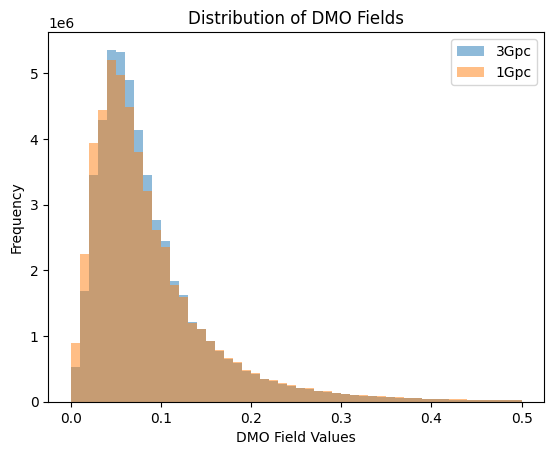

In [14]:
plt.figure()
_ = plt.hist(np.log(1+dmo_3gpc_sel[:100000,...,0].flatten()), bins=50, range=(0,0.5), alpha=0.5, label='3Gpc')
_ = plt.hist(np.log(1+dmo_1gpc_sel[:100000,...,0].flatten()), bins=50, range=(0,0.5), alpha=0.5, label='1Gpc')
plt.xlabel('DMO Field Values')
plt.ylabel('Frequency')
plt.title('Distribution of DMO Fields')
plt.legend()
plt.show()


